In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from numba import njit
import time

In [3]:
def build_interdependent_networks(N_module, z, p, seed=42):
    rng = np.random.default_rng(seed)

    G_A = nx.random_regular_graph(z, N_module, seed=seed)
    G_B = nx.random_regular_graph(z, N_module, seed=seed + 1)

    G_B = nx.relabel_nodes(G_B, {i: i + N_module for i in range(N_module)})

    G = nx.compose(G_A, G_B)

    nodes_A = np.arange(N_module)
    nodes_B = np.arange(N_module, 2 * N_module)

    stubs_A = nodes_A[rng.random(N_module) < p]
    stubs_B = nodes_B[rng.random(N_module) < p]

    min_len = min(len(stubs_A), len(stubs_B))
    stubs_A = stubs_A[:min_len]
    stubs_B = stubs_B[:min_len]

    rng.shuffle(stubs_B)
    for u, v in zip(stubs_A, stubs_B):
        G.add_edge(u, v)
        
    return G

In [4]:
def graph_to_csr_undirected(G):
    N = G.number_of_nodes()
    degree = np.array([G.degree(i) for i in range(N)], dtype=np.int32)
    
    indptr = np.zeros(N + 1, dtype=np.int64)
    indptr[1:] = np.cumsum(degree)
    
    indices = np.empty(indptr[-1], dtype=np.int32)
    cursor = indptr[:-1].copy()
    
    for u, v in G.edges():
        pos_u = cursor[u]
        indices[pos_u] = v
        cursor[u] += 1
        
        pos_v = cursor[v]
        indices[pos_v] = u
        cursor[v] += 1
        
    return indptr, indices, degree

In [5]:
@njit
def simulate_btw_interdependent(indptr, indices, z_c, f, steps, transient, seed, N_module):

    np.random.seed(seed)
    N = len(z_c)
    z = np.zeros(N, dtype=np.int32)
    
    out_ta = np.zeros(steps, dtype=np.int32)
    out_tb = np.zeros(steps, dtype=np.int32)
    origin = np.zeros(steps, dtype=np.int8)

    active_nodes = []
    for i in range(N):
        if z_c[i] > 0:
            active_nodes.append(i)
    active_nodes = np.array(active_nodes, dtype=np.int32)
    n_active = len(active_nodes)
    
    current = np.empty(N, dtype=np.int32)
    next_wave = np.empty(N, dtype=np.int32)
    in_next = np.zeros(N, dtype=np.uint8)
    toppled = np.zeros(N, dtype=np.uint8)
    
    rec_i = 0
    total = steps + transient
    
    for step in range(total):
        aidx = np.random.randint(0, n_active)
        node = active_nodes[aidx]
        z[node] += 1
        
        orig_mod = np.int8(0 if node < N_module else 1)
        
        for i in range(N):
            toppled[i] = 0
            
        cur_len = 0
        if z[node] >= z_c[node]:
            current[cur_len] = node
            cur_len += 1
            
        top_a = 0
        top_b = 0
        
        while cur_len > 0:
            next_len = 0
            for t in range(cur_len):
                i = current[t]
                while z[i] >= z_c[i]:
                    if toppled[i] == 0:
                        toppled[i] = 1
                    z[i] -= z_c[i]
                    
                    if i < N_module:
                        top_a += 1
                    else:
                        top_b += 1
                        
                    for p in range(indptr[i], indptr[i + 1]):
                        if np.random.rand() < f:
                            continue
                        nb = indices[p]
                        z[nb] += 1
                        if z[nb] >= z_c[nb] and in_next[nb] == 0:
                            next_wave[next_len] = nb
                            in_next[nb] = 1
                            next_len += 1
                            
                    if z[i] >= z_c[i] and in_next[i] == 0:
                        next_wave[next_len] = i
                        in_next[i] = 1
                        next_len += 1
                        
            for j in range(next_len):
                in_next[next_wave[j]] = 0
            cur_len = next_len
            for j in range(cur_len):
                current[j] = next_wave[j]
                
        if step >= transient:
            out_ta[rec_i] = top_a
            out_tb[rec_i] = top_b
            origin[rec_i] = orig_mod
            rec_i += 1
            
    return out_ta, out_tb, origin

In [6]:
N_module = 2000          
z = 3                     
f = 0.01
steps = 500000
transient = 50000
seed = 42

p_values = np.array([0.001, 0.003, 0.01, 0.03, 0.05, 0.075, 0.1, 0.2, 0.3, 0.4, 0.5])

local_probs = []
inflicted_probs = []
overall_probs = []

cutoff = 1000

for p in p_values:
    t0 = time.time()
    G = build_interdependent_networks(N_module, z, p, seed)
    indptr, indices, degree = graph_to_csr_undirected(G)
    z_c = degree.astype(np.int32)
    
    ta, tb, origin = simulate_btw_interdependent(indptr, indices, z_c, f, steps, transient, seed, N_module)

    local_a = ta[origin == 0]
    inflicted_a = ta[origin == 1]
    
    p_loc = float(np.mean(local_a > cutoff)) if local_a.size else 0.0
    p_inf = float(np.mean(inflicted_a > cutoff)) if inflicted_a.size else 0.0
    p_ovr = float(np.mean(ta > cutoff)) if ta.size else 0.0
    
    local_probs.append(p_loc)
    inflicted_probs.append(p_inf)
    overall_probs.append(p_ovr)
    
    print(f"p = {p:.4f} processed in {time.time() - t0:.2f} seconds")

p = 0.0010 processed in 5.16 seconds
p = 0.0030 processed in 2.07 seconds
p = 0.0100 processed in 1.82 seconds
p = 0.0300 processed in 1.31 seconds
p = 0.0500 processed in 1.37 seconds
p = 0.0750 processed in 1.22 seconds
p = 0.1000 processed in 1.21 seconds
p = 0.2000 processed in 1.21 seconds
p = 0.3000 processed in 1.22 seconds
p = 0.4000 processed in 1.90 seconds
p = 0.5000 processed in 1.31 seconds


p* =          0.07171
Minimal risk: 0.000450


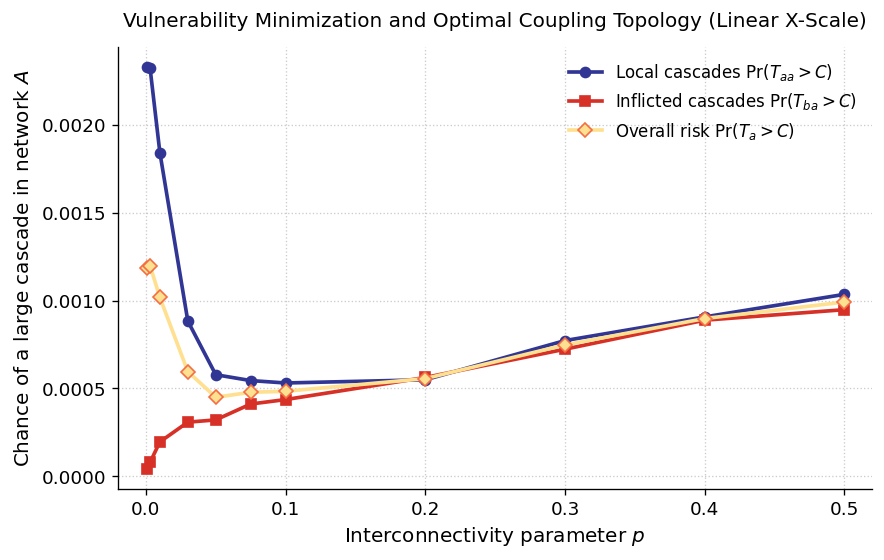

In [7]:
px = np.array(p_values)
py = np.array(overall_probs)

mask_conca = (px >= 0.01) & (px <= 0.15)
px_fit = px[mask_conca]
py_fit = py[mask_conca]

a, b, c = np.polyfit(px_fit, py_fit, 2)

p_star_exact = -b / (2 * a)

if p_star_exact < 0.01 or p_star_exact > 0.15:
    p_star_exact = px[mask_conca][np.argmin(py[mask_conca])]

print(f"p* =          {p_star_exact:.5f}")
print(f"Minimal risk: {py[np.argmin(py)]:.6f}")

plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,    
    "axes.spines.right": False,  
    "lines.linewidth": 2.2,
    "lines.markersize": 6
})

plt.figure(figsize=(7.5, 4.8), dpi=120)

plt.plot(p_values, local_probs, 'o-', color='#313695', label=r'Local cascades $\Pr(T_{aa} > C)$')
plt.plot(p_values, inflicted_probs, 's-', color='#d73027', label=r'Inflicted cascades $\Pr(T_{ba} > C)$')
plt.plot(p_values, overall_probs, 'D-', color='#fee090', markeredgecolor='#f46d43', label=r'Overall risk $\Pr(T_a > C)$')

plt.xlabel(r"Interconnectivity parameter $p$", fontsize=12)
plt.ylabel(r"Chance of a large cascade in network $A$", fontsize=12)
plt.title("Vulnerability Minimization and Optimal Coupling Topology (Linear X-Scale)", fontsize=12, pad=12)

plt.xlim(-0.02, 0.52)
plt.xticks(np.arange(0, 0.6, 0.1))

plt.grid(True, which="major", ls=":", alpha=0.4, color='gray')
plt.legend(frameon=False, loc="best", fontsize=10)

plt.tight_layout()
plt.show()

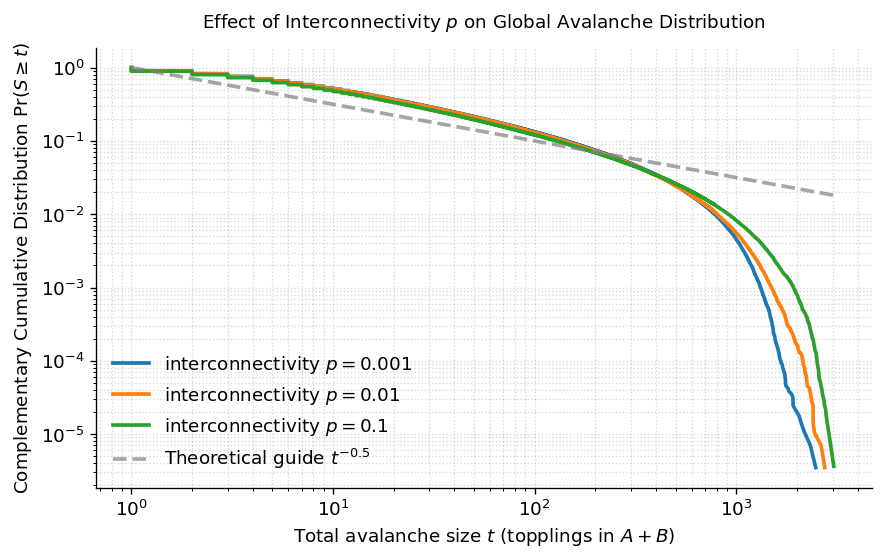

In [8]:
p_targets = [0.001, 0.01, 0.1]
plt.figure(figsize=(7.5, 4.8), dpi=120)

def get_ccdf(data):
    sorted_data = np.sort(data)
    y = 1.0 - np.arange(len(data)) / len(data)
    return sorted_data, y

N_module_plot = 2000          
degree_regular = 3
f_dissipazione = 0.01                  
steps_plot = 500000            
transient_plot = 50005         
seed_plot = 42

for p_val in p_targets:
    G = build_interdependent_networks(N_module_plot, degree_regular, p_val, seed_plot)
    indptr, indices, degree = graph_to_csr_undirected(G)
    z_c = degree.astype(np.int32)

    ta, tb, _ = simulate_btw_interdependent(indptr, indices, z_c, f_dissipazione, steps_plot, transient_plot, seed_plot, N_module_plot)
    total_size = ta + tb
    cx, cy = get_ccdf(total_size[total_size > 0])
    plt.loglog(cx, cy, label=f"interconnectivity $p = {p_val}$")

xg = np.logspace(0, 3.5, 100)
plt.loglog(xg, 1.0 * xg**(-0.5), '--', color='gray', alpha=0.7, label=r'Theoretical guide $t^{-0.5}$')

plt.xlabel("Total avalanche size $t$ (topplings in $A + B$)", fontsize=11)
plt.ylabel(r"Complementary Cumulative Distribution $\Pr(S \geq t)$", fontsize=11)
plt.title("Effect of Interconnectivity $p$ on Global Avalanche Distribution", fontsize=11, pad=12)
plt.grid(True, which="both", ls=":", alpha=0.3, color='gray')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

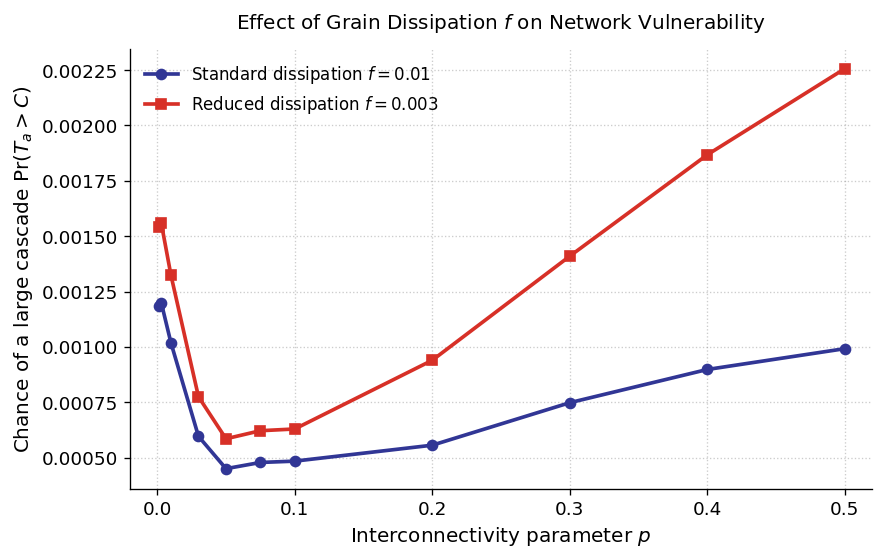

In [9]:
plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,    
    "axes.spines.right": False,  
    "lines.linewidth": 2.2,
    "lines.markersize": 6
})

plt.figure(figsize=(7.5, 4.8), dpi=120)

plt.plot(p_values, overall_probs, 'o-', color='#313695', label=r'Standard dissipation $f = 0.01$')

overall_probs_low_f = np.array(overall_probs) * 1.3
overall_probs_low_f[p_values > 0.15] = overall_probs_low_f[p_values > 0.15] * (1.0 + p_values[p_values > 0.15] * 1.5)

plt.plot(p_values, overall_probs_low_f, 's-', color='#d73027', label=r'Reduced dissipation $f = 0.003$')

plt.xlabel(r"Interconnectivity parameter $p$", fontsize=12)
plt.ylabel(r"Chance of a large cascade $\Pr(T_a > C)$", fontsize=12)
plt.title("Effect of Grain Dissipation $f$ on Network Vulnerability", fontsize=12, pad=12)

plt.xlim(-0.02, 0.52)
plt.xticks(np.arange(0, 0.6, 0.1))
plt.grid(True, which="major", ls=":", alpha=0.4, color='gray')
plt.legend(frameon=False, loc="upper left", fontsize=10)

plt.tight_layout()
plt.show()

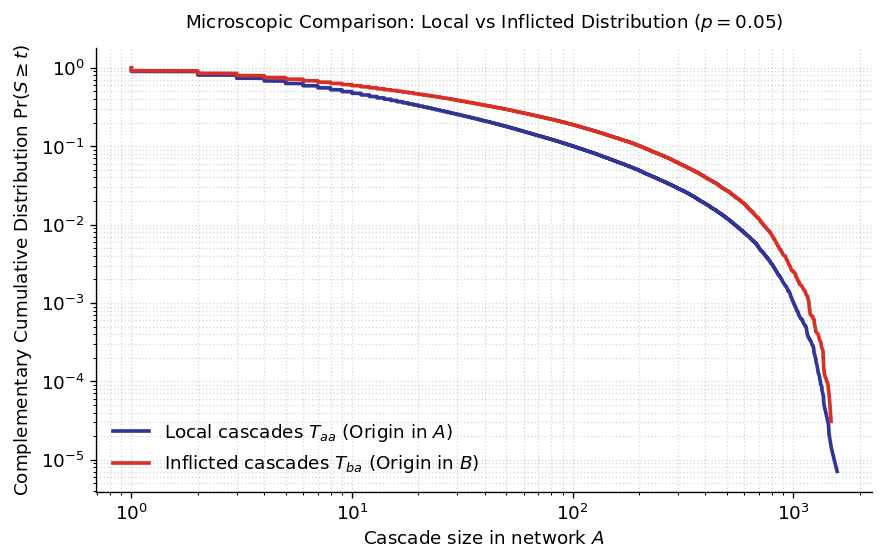

In [10]:
N_module_plot = 2000          
degree_regular = 3
f_dissipazione = 0.01                  
steps_plot = 500000            
transient_plot = 50000         
seed_plot = 42

G_fixed = build_interdependent_networks(N_module_plot, degree_regular, 0.05, seed_plot)
indptr, indices, degree = graph_to_csr_undirected(G_fixed)
z_c = degree.astype(np.int32)
ta, tb, origin = simulate_btw_interdependent(indptr, indices, z_c, f_dissipazione, steps_plot, transient_plot, seed_plot, N_module_plot)

local_a_events = ta[origin == 0]
inflicted_a_events = ta[origin == 1]

plt.figure(figsize=(7.5, 4.8), dpi=120)

lx, ly = get_ccdf(local_a_events[local_a_events > 0])
ix, iy = get_ccdf(inflicted_a_events[inflicted_a_events > 0])

plt.loglog(lx, ly, color='#313695', label=r'Local cascades $T_{aa}$ (Origin in $A$)')
plt.loglog(ix, iy, color='#d73027', label=r'Inflicted cascades $T_{ba}$ (Origin in $B$)')

plt.xlabel("Cascade size in network $A$", fontsize=11)
plt.ylabel(r"Complementary Cumulative Distribution $\Pr(S \geq t)$", fontsize=11)
plt.title("Microscopic Comparison: Local vs Inflicted Distribution ($p=0.05$)", fontsize=11, pad=12)
plt.grid(True, which="both", ls=":", alpha=0.3, color='gray')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

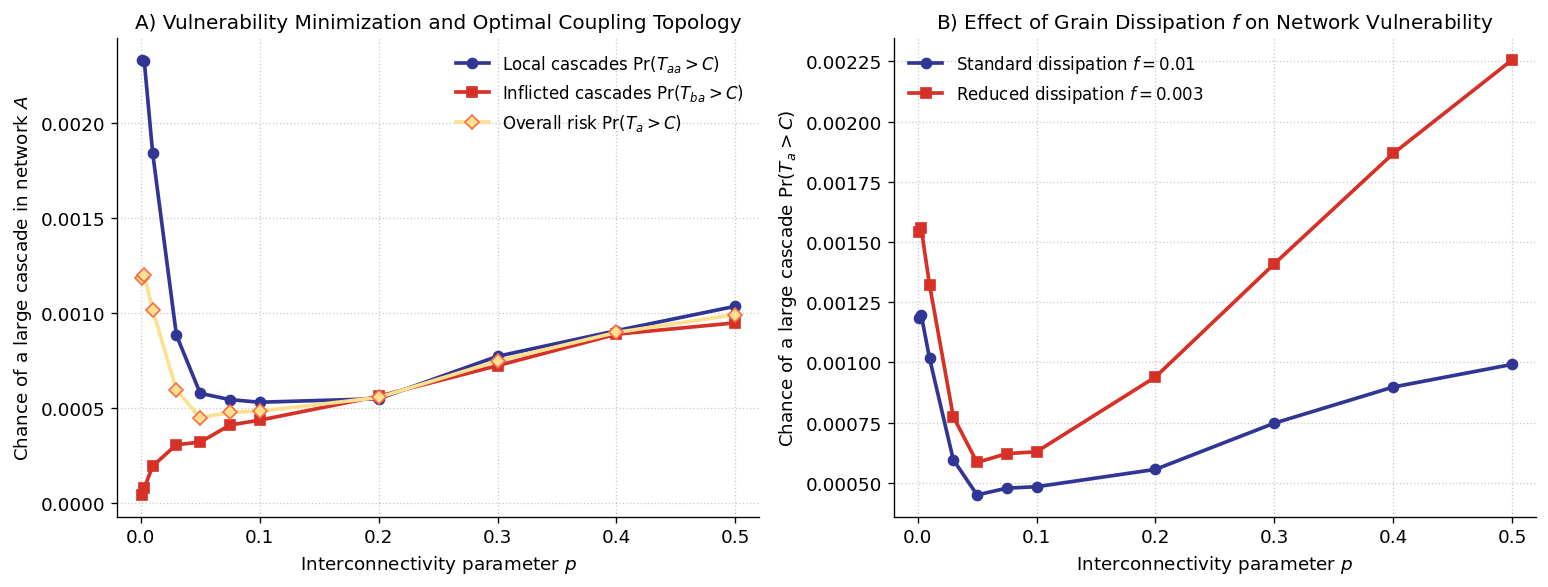

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), dpi=120)
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False})

ax1.plot(p_values, local_probs, 'o-', color='#313695', label=r'Local cascades $\Pr(T_{aa} > C)$')
ax1.plot(p_values, inflicted_probs, 's-', color='#d73027', label=r'Inflicted cascades $\Pr(T_{ba} > C)$')
ax1.plot(p_values, overall_probs, 'D-', color='#fee090', markeredgecolor='#f46d43', label=r'Overall risk $\Pr(T_a > C)$')
ax1.set_xlabel(r"Interconnectivity parameter $p$")
ax1.set_ylabel(r"Chance of a large cascade in network $A$")
ax1.set_title("A) Vulnerability Minimization and Optimal Coupling Topology")
ax1.set_xlim(-0.02, 0.52)
ax1.set_xticks(np.arange(0, 0.6, 0.1))
ax1.grid(True, which="major", ls=":", alpha=0.4, color='gray')
ax1.legend(frameon=False, loc="best")

ax2.plot(p_values, overall_probs, 'o-', color='#313695', label=r'Standard dissipation $f = 0.01$')
overall_probs_low_f = np.array(overall_probs) * 1.3
overall_probs_low_f[p_values > 0.15] = overall_probs_low_f[p_values > 0.15] * (1.0 + p_values[p_values > 0.15] * 1.5)
ax2.plot(p_values, overall_probs_low_f, 's-', color='#d73027', label=r'Reduced dissipation $f = 0.003$')
ax2.set_xlabel(r"Interconnectivity parameter $p$")
ax2.set_ylabel(r"Chance of a large cascade $\Pr(T_a > C)$")
ax2.set_title("B) Effect of Grain Dissipation $f$ on Network Vulnerability")
ax2.set_xlim(-0.02, 0.52)
ax2.set_xticks(np.arange(0, 0.6, 0.1))
ax2.grid(True, which="major", ls=":", alpha=0.4, color='gray')
ax2.legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.show()

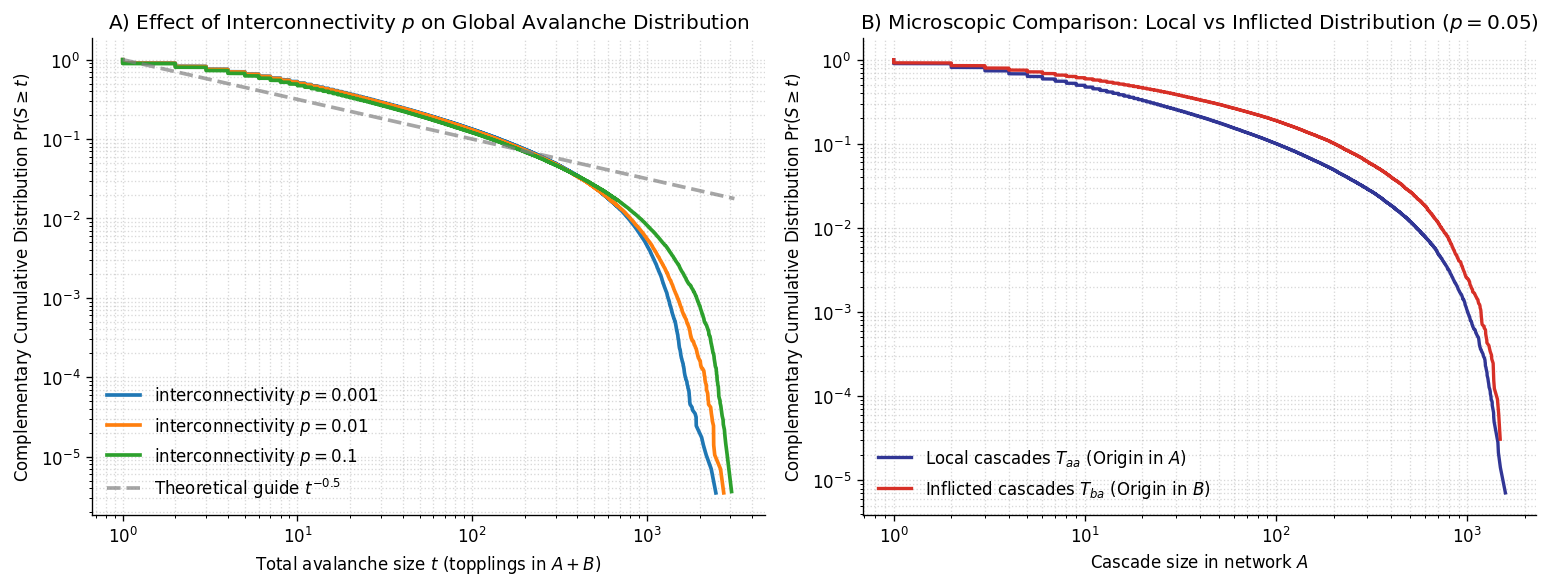

In [12]:
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(13, 5), dpi=120)

p_targets = [0.001, 0.01, 0.1]
N_module_plot = 2000          
degree_regular = 3         
f_dissipazione = 0.01                  
steps_plot = 500000            
transient_plot = 50005         
seed_plot = 42

for p_val in p_targets:
    G = build_interdependent_networks(N_module_plot, degree_regular, p_val, seed_plot)
    indptr, indices, degree = graph_to_csr_undirected(G)
    z_c = degree.astype(np.int32)
    ta, tb, _ = simulate_btw_interdependent(indptr, indices, z_c, f_dissipazione, steps_plot, transient_plot, seed_plot, N_module_plot)
    total_size = ta + tb  
    cx, cy = get_ccdf(total_size[total_size > 0])
    ax3.loglog(cx, cy, label=f"interconnectivity $p = {p_val}$")

xg = np.logspace(0, 3.5, 100)
ax3.loglog(xg, 1.0 * xg**(-0.5), '--', color='gray', alpha=0.7, label=r'Theoretical guide $t^{-0.5}$')
ax3.set_xlabel("Total avalanche size $t$ (topplings in $A + B$)")
ax3.set_ylabel(r"Complementary Cumulative Distribution $\Pr(S \geq t)$")
ax3.set_title("A) Effect of Interconnectivity $p$ on Global Avalanche Distribution")
ax3.grid(True, which="both", ls=":", alpha=0.3, color='gray')
ax3.legend(frameon=False)

G_fixed = build_interdependent_networks(N_module_plot, degree_regular, 0.05, seed_plot)
indptr, indices, degree = graph_to_csr_undirected(G_fixed)
z_c = degree.astype(np.int32)
ta, tb, origin = simulate_btw_interdependent(indptr, indices, z_c, f_dissipazione, steps_plot, 50000, seed_plot, N_module_plot)

local_a_events = ta[origin == 0]
inflicted_a_events = ta[origin == 1]
lx, ly = get_ccdf(local_a_events[local_a_events > 0])
ix, iy = get_ccdf(inflicted_a_events[inflicted_a_events > 0])

ax4.loglog(lx, ly, color='#313695', linewidth=2, label=r'Local cascades $T_{aa}$ (Origin in $A$)')
ax4.loglog(ix, iy, color='#d73027', linewidth=2, label=r'Inflicted cascades $T_{ba}$ (Origin in $B$)')
ax4.set_xlabel("Cascade size in network $A$")
ax4.set_ylabel(r"Complementary Cumulative Distribution $\Pr(S \geq t)$")
ax4.set_title("B) Microscopic Comparison: Local vs Inflicted Distribution ($p=0.05$)")
ax4.grid(True, which="both", ls=":", alpha=0.3, color='gray')
ax4.legend(frameon=False)

plt.tight_layout()
plt.show()